# Introducción a OpenCV y espacios de color

En este cuaderno vas a trabajar con las primeras operaciones de visión por computadora usando OpenCV. La idea no es solo ejecutar funciones, sino entender qué representa cada transformación y por qué conviene usarla según la tarea.


## Objetivo

Comprender cómo una misma imagen puede representarse de distintas maneras y cómo esas representaciones cambian lo que resulta fácil o difícil de analizar.

## Resultados de aprendizaje

Al finalizar este cuaderno, vas a poder:

- cargar una imagen con OpenCV y visualizarla correctamente con Matplotlib;
- explicar la diferencia entre RGB, escala de grises y HSV;
- analizar qué información aporta cada canal de color;
- aplicar ajustes básicos de brillo y contraste;
- construir una segmentación sencilla por color usando máscaras.


## Relación con la unidad

Este cuaderno funciona como una introducción a la unidad de procesamiento de imágenes. Acá vas a construir una base conceptual que después se retoma en temas como transformaciones geométricas, análisis de contornos, detección de objetos y preprocesamiento para modelos de aprendizaje automático.


## Módulos que vamos a usar

Antes de empezar con el código, conviene ubicar qué hace cada biblioteca:

- `cv2`: es la biblioteca principal de OpenCV. La usamos para leer imágenes, convertir espacios de color y construir máscaras.
- `numpy`: nos permite trabajar con arreglos numéricos. En imágenes, esos arreglos representan filas, columnas y canales.
- `matplotlib.pyplot`: la usamos para mostrar imágenes y comparar resultados dentro del cuaderno.
- `pathlib.Path`: nos ayuda a construir rutas de archivos de una manera clara y portátil.


In [5]:
# Importamos Path para construir rutas de archivos de forma portable.
from pathlib import Path

# Importamos OpenCV para leer y procesar imágenes.
import cv2

# Importamos NumPy para trabajar con arreglos numéricos.
import numpy as np

# Importamos Matplotlib para mostrar imágenes y gráficos.
import matplotlib.pyplot as plt

# Definimos la ruta de la imagen principal que usaremos en los ejemplos.
ruta_imagen_principal = Path('Imagenes') / 'messi.jpg'

# Definimos la ruta de la imagen que usaremos para segmentación por color.
ruta_imagen_segmentacion = Path('Imagenes') / 'globos.jpg'

# Mostramos la carpeta actual desde la que se ejecuta el cuaderno.
print(f'Carpeta actual: {Path.cwd()}')

# Mostramos la ruta relativa de la imagen principal.
print(f'Imagen principal: {ruta_imagen_principal}')

# Mostramos la ruta completa de la imagen principal.
print(f'Ruta completa imagen principal: {ruta_imagen_principal.resolve()}')


# Mostramos la ruta relativa de la imagen de segmentación.
print(f'Imagen para segmentación: {ruta_imagen_segmentacion}')

# Mostramos la ruta completa de la imagen de segmentación.
print(f'Ruta completa imagen segmentación: {ruta_imagen_segmentacion.resolve()}')

# Verificamos si el archivo de la imagen principal existe.
print(f'Existe imagen principal: {ruta_imagen_principal.exists()}')

# Verificamos si el archivo de la imagen de segmentación existe.
print(f'Existe imagen segmentación: {ruta_imagen_segmentacion.exists()}')




Carpeta actual: c:\Users\carme\OneDrive\Documents\Procesamiento de imágenes\rodriguez-carmen-pdi-1c-2026\005  - computer_vision_parte_1\002 - PRA
Imagen principal: Imagenes\messi.jpg
Ruta completa imagen principal: C:\Users\carme\OneDrive\Documents\Procesamiento de imágenes\rodriguez-carmen-pdi-1c-2026\005  - computer_vision_parte_1\002 - PRA\Imagenes\messi.jpg
Imagen para segmentación: Imagenes\globos.jpg
Ruta completa imagen segmentación: C:\Users\carme\OneDrive\Documents\Procesamiento de imágenes\rodriguez-carmen-pdi-1c-2026\005  - computer_vision_parte_1\002 - PRA\Imagenes\globos.jpg
Existe imagen principal: True
Existe imagen segmentación: True


## 1. Cargar una imagen y verla correctamente

En este primer bloque vas a cargar una imagen con OpenCV. Este paso tiene una particularidad importante: OpenCV guarda los canales de color en orden BGR, mientras que Matplotlib espera RGB. Si no hacemos la conversión, los colores se ven alterados.

En el resultado esperable deberías obtener una imagen color con tres canales y datos de forma legible sobre sus dimensiones.


In [6]:
# Leemos la imagen principal desde la carpeta del proyecto.
imagen_bgr = cv2.imread(str(ruta_imagen_principal))

# Verificamos que el archivo se haya cargado correctamente.
if imagen_bgr is None:
    raise FileNotFoundError(f'No se pudo leer la imagen: {ruta_imagen_principal}')

# Convertimos la imagen de BGR a RGB para verla bien con Matplotlib.
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

# Mostramos información básica para reconocer la estructura del arreglo.
print(f'Dimensiones de la imagen: {imagen_rgb.shape}')
print(f'Tipo de dato: {imagen_rgb.dtype}')


Dimensiones de la imagen: (417, 625, 3)
Tipo de dato: uint8


Fijate que la forma de la imagen aparece como una tupla con tres valores: alto, ancho y cantidad de canales. En una imagen RGB, el último valor suele ser `3`, porque cada píxel guarda información de rojo, verde y azul.


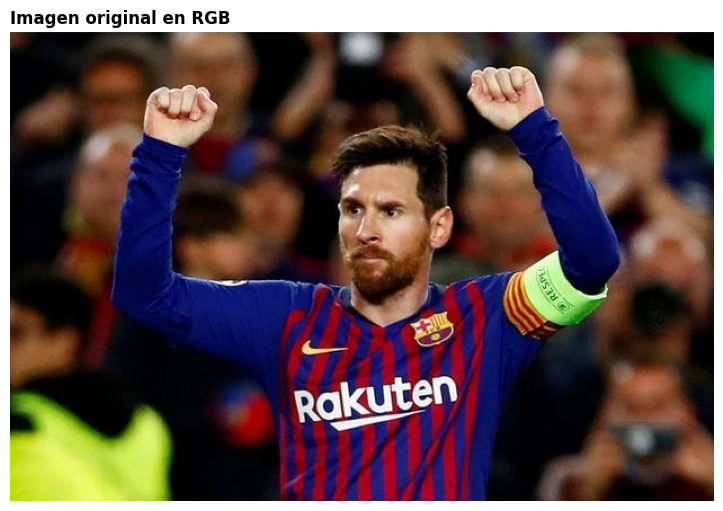

In [7]:
# Mostramos la imagen original ya convertida a RGB.
plt.figure(figsize=(10, 5), constrained_layout=True)
plt.imshow(imagen_rgb)
plt.title('Imagen original en RGB', fontweight='bold', loc='left')
plt.axis('off')
plt.show()
# Visualizamos la imagen ya convertida a RGB para comprobar que los colores se 
# muestren correctamente en Matplotlib.



Observá si los colores se ven naturales. Si la camiseta, la piel y el fondo tienen tonos razonables, la conversión de BGR a RGB quedó bien hecha. Este control inicial es importante, porque un error en esta etapa arrastra problemas al resto del análisis.


## 2. Convertir la imagen a escala de grises

Ahora vas a pasar de una imagen con tres canales a una imagen con un solo canal de intensidad. La escala de grises simplifica la información visual y suele ser útil cuando el color no es indispensable, por ejemplo en tareas de bordes, formas o texturas.


In [8]:
# Convertimos la imagen RGB a escala de grises.
imagen_gris = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2GRAY)

# Verificamos la forma para confirmar que ahora solo hay un canal.
print(f'Dimensiones de la imagen en grises: {imagen_gris.shape}')


Dimensiones de la imagen en grises: (417, 625)


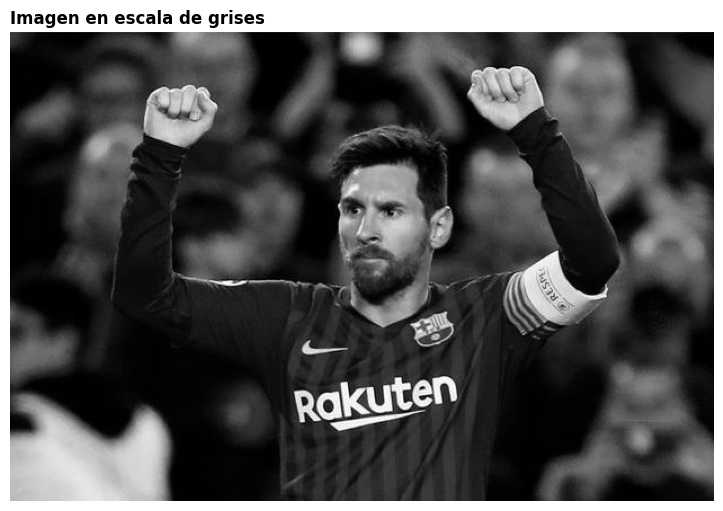

In [ ]:
# Mostramos la imagen en escala de grises.
# Creamos una figura para mostrar la imagen en un tamaño más cómodo.
plt.figure(figsize=(10, 5), constrained_layout=True)

# Mostramos la imagen en escala de grises usando el mapa de color adecuado.
plt.imshow(imagen_gris, cmap='gray')

# Agregamos un título descriptivo al gráfico.
plt.title('Imagen en escala de grises', fontweight='bold', loc='left')

# Ocultamos los ejes para visualizar solo la imagen.
plt.axis('off')

# Renderizamos la figura en pantalla.
plt.show()

#matplolib


En esta representación ya no ves color, pero seguís viendo estructura, contraste y distribución de luces y sombras. Eso muestra una idea importante: muchas tareas de visión no necesitan toda la información disponible, sino una representación adecuada para el problema que queremos resolver.

En este caso, pasar la imagen a escala de grises sirve para trabajar con una sola intensidad de luz por píxel en lugar de tres canales de color. Eso simplifica mucho el análisis y permite enfocarse en la forma, los bordes, el contraste y la textura sin que influya el color.

Para esta práctica es útil porque reduce la información a procesar, haciendo más simple el tratamiento de la imagen; facilita operaciones como detección de bordes, umbralización y segmentación básica; permite ver con claridad diferencias de iluminación entre zonas claras y oscuras.


## 3. Convertir la imagen a HSV

HSV representa la imagen de otra manera. En lugar de mezclar rojo, verde y azul, separa el color puro del brillo. Esta separación resulta especialmente útil cuando queremos detectar objetos por color sin depender tanto de cambios de iluminación.

H - Hue / Tono: qué color es, por ejemplo rojo, azul, verde, amarillo.

S - Saturation / Saturación: qué tan puro o intenso es ese color. Un color muy saturado se ve vivo; uno poco saturado se acerca al gris.

V - Value / Valor o brillo: qué tan claro u oscuro es el píxel.

In [10]:
# Convertimos la imagen RGB al espacio de color HSV.
imagen_hsv = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2HSV)

# Mostramos algunos valores para recordar que HSV también es una representación numérica.
print(f'Dimensiones de la imagen en HSV: {imagen_hsv.shape}')
print(f'Rango del canal H: {imagen_hsv[:, :, 0].min()} a {imagen_hsv[:, :, 0].max()}')


Dimensiones de la imagen en HSV: (417, 625, 3)
Rango del canal H: 0 a 179


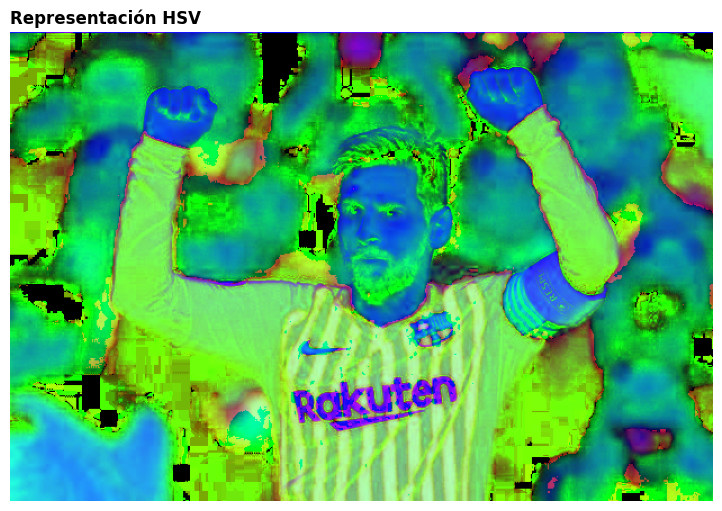

In [11]:
# Visualizamos la imagen HSV.
# El resultado no se ve natural porque Matplotlib interpreta los datos como si fueran RGB.
plt.figure(figsize=(10, 5), constrained_layout=True)
plt.imshow(imagen_hsv)
plt.title('Representación HSV', fontweight='bold', loc='left')
plt.axis('off')
plt.show()


Esta visualización no coincide con el aspecto real de la escena, pero sigue siendo útil para analizar cómo quedó organizada la información. En HSV, el color y el brillo quedan más desacoplados que en RGB, y eso suele facilitar la segmentación por rangos cromáticos.


La imagen HSV puede servir para:

detectar zonas con un color determinado, como la camiseta; 

separar mejor regiones según su tono, saturación y brillo;

hacer máscaras de color más estables que en RGB;

analizar cómo influye la iluminación sin mezclarla directamente con el color.

La idea clave es que en RGB el color y el brillo están mezclados, mientras que en HSV quedan más separados. Entonces, si quiero identificar partes de la imagen por color, HSV suele ser más práctico.

“Convertir la imagen a HSV permite representar el color de una manera más conveniente para segmentar regiones específicas, ya que separa el tono, la saturación y el brillo.”


## 4. Comparar tres representaciones de la misma imagen

La escena no cambió. Lo que cambió es la manera de describirla numéricamente. Comparar estas tres versiones sirve para decidir qué representación conviene según la tarea.


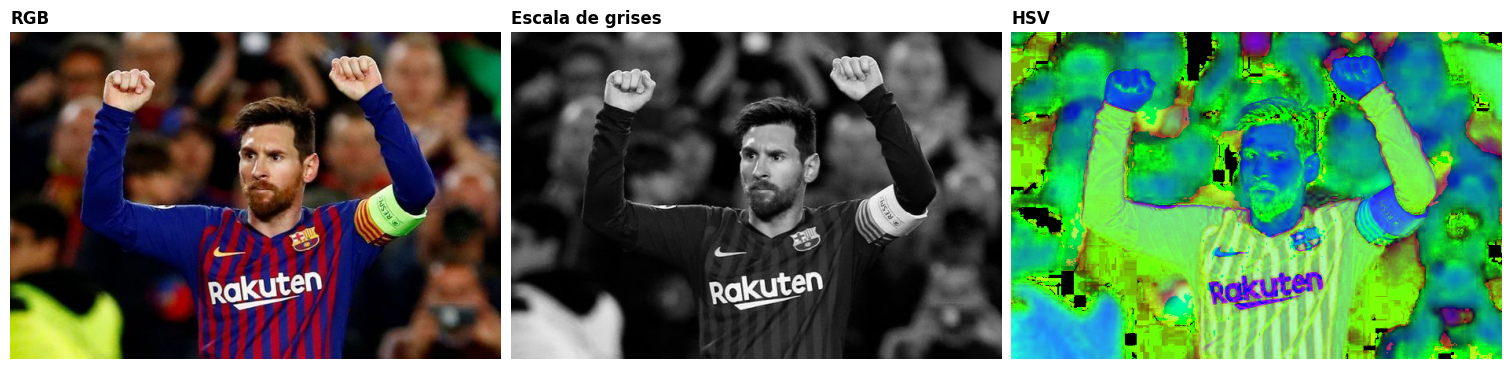

In [12]:
# Creamos una figura con tres subgráficos para comparar representaciones.
fig, ejes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

# Mostramos la imagen RGB.
ejes[0].imshow(imagen_rgb)
ejes[0].set_title('RGB', fontweight='bold', loc='left')
ejes[0].axis('off')

# Mostramos la imagen en escala de grises.
ejes[1].imshow(imagen_gris, cmap='gray')
ejes[1].set_title('Escala de grises', fontweight='bold', loc='left')
ejes[1].axis('off')

# Mostramos la imagen HSV tal como queda almacenada.
ejes[2].imshow(imagen_hsv)
ejes[2].set_title('HSV', fontweight='bold', loc='left')
ejes[2].axis('off')

plt.show()


Observá que RGB conserva la apariencia natural de la escena, la escala de grises resume la información en intensidad luminosa y HSV separa el color del brillo. Esta última propiedad suele ser especialmente útil cuando queremos detectar objetos por color aun si cambia la iluminación.


## 5. Separar los canales de color

Una imagen color no es un bloque indivisible. En realidad, está compuesta por canales. Separarlos permite entender qué información aporta cada parte y por qué algunos algoritmos trabajan mejor sobre ciertos canales que sobre otros. Separar los canales de color permite analizar por separado la información que compone la imagen, lo que facilita la identificación de colores, niveles de brillo y regiones de interés para su posterior procesamiento.

En la práctica sirve para:

identificar qué canal resalta mejor ciertas zonas u objetos;

detectar diferencias de color que en la imagen completa pasan desapercibidas;

facilitar tareas de segmentación, umbralización y filtrado;

entender cómo está compuesta la imagen según el espacio de color usado.

Por ejemplo:

en RGB, separar canales permite ver cuánto aporta rojo, verde y azul;

en HSV, separar canales permite distinguir tono, saturación y brillo;

en escala de grises ya no hay separación de color, porque solo queda intensidad luminosa.


In [15]:
# Separamos los canales de la imagen RGB.
canal_rojo, canal_verde, canal_azul = cv2.split(imagen_rgb)

# Separamos también los canales de la imagen HSV.
canal_matiz, canal_saturacion, canal_valor = cv2.split(imagen_hsv)

# Confirmamos que cada canal es una matriz bidimensional.
print(f'Forma del canal rojo: {canal_rojo.shape}')
print(f'Forma del canal matiz: {canal_matiz.shape}')

# Separamos los canales de color de las imágenes RGB y HSV para analizarlos individualmente y
#  verificar su estructura.



Forma del canal rojo: (417, 625)
Forma del canal matiz: (417, 625)


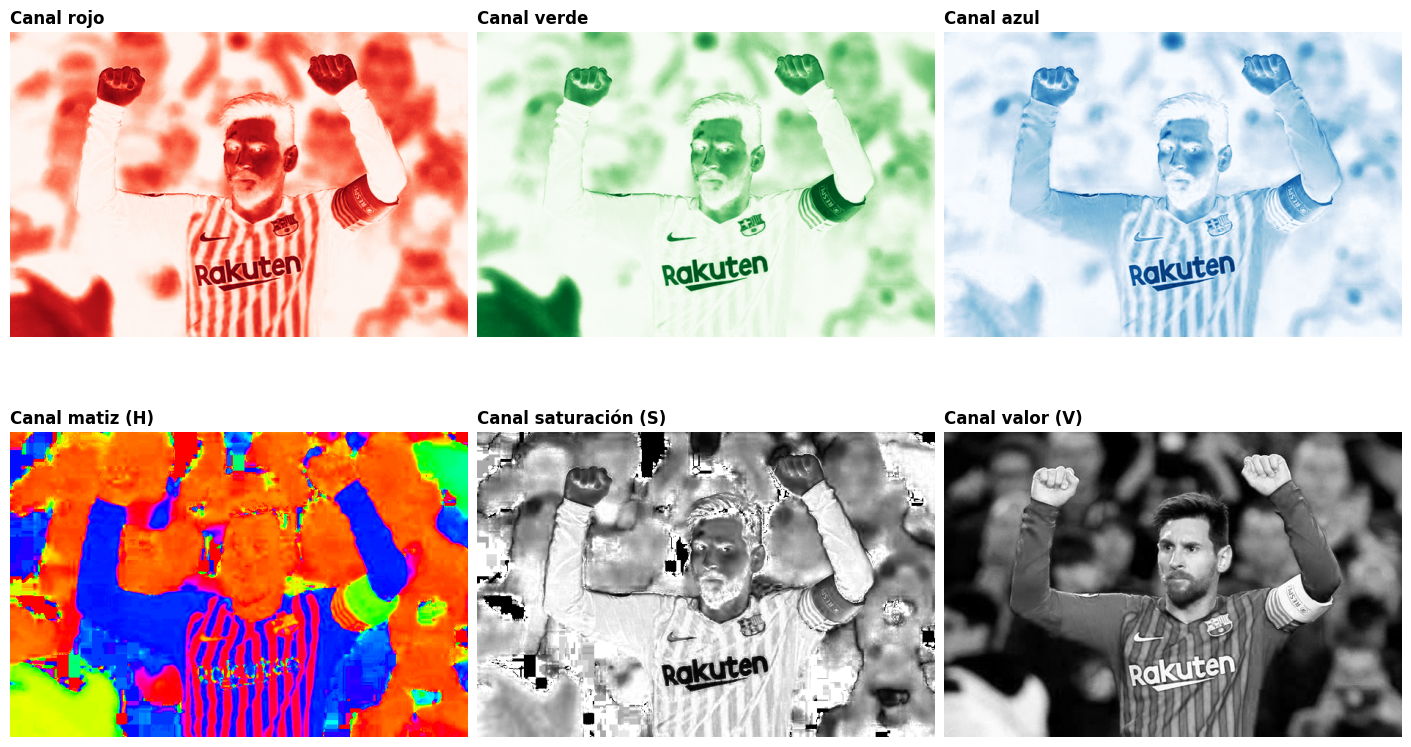

In [16]:
# Organizamos los seis canales en una cuadrícula para compararlos.
fig, ejes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

# Visualizamos los canales RGB con mapas de color asociados.
ejes[0, 0].imshow(canal_rojo, cmap='Reds')
ejes[0, 0].set_title('Canal rojo', fontweight='bold', loc='left')
ejes[0, 0].axis('off')

ejes[0, 1].imshow(canal_verde, cmap='Greens')
ejes[0, 1].set_title('Canal verde', fontweight='bold', loc='left')
ejes[0, 1].axis('off')

ejes[0, 2].imshow(canal_azul, cmap='Blues')
ejes[0, 2].set_title('Canal azul', fontweight='bold', loc='left')
ejes[0, 2].axis('off')

# Visualizamos los canales HSV.
ejes[1, 0].imshow(canal_matiz, cmap='hsv')
ejes[1, 0].set_title('Canal matiz (H)', fontweight='bold', loc='left')
ejes[1, 0].axis('off')

ejes[1, 1].imshow(canal_saturacion, cmap='gray')
ejes[1, 1].set_title('Canal saturación (S)', fontweight='bold', loc='left')
ejes[1, 1].axis('off')

ejes[1, 2].imshow(canal_valor, cmap='gray')
ejes[1, 2].set_title('Canal valor (V)', fontweight='bold', loc='left')
ejes[1, 2].axis('off')

plt.show()


Fijate que cada canal resalta aspectos distintos de la escena. En RGB, los canales están ligados al modo en que mezclamos colores para ver la imagen. En HSV, en cambio, `H` describe el tono, `S` la intensidad del color y `V` el brillo general. Esa diferencia explica por qué HSV suele ser más práctico para segmentar por color.


De este set  se puede extraer info de cómo está compuesta la imagen según distintos criterios: cantidad de rojo, verde, azul, tono, pureza del color y brillo. Eso ayuda a decidir qué representación conviene usar según lo que se quiere detectar o segmentar.

En los canales RGB:

Canal rojo: las zonas claras tienen mayor presencia de rojo. Acá resalta bastante la piel y partes cálidas de la escena.

Canal verde: muestra dónde el verde aporta más intensidad. Puede servir para comparar fondo, césped o zonas menos rojizas.

Canal azul: las zonas claras tienen más componente azul. En una camiseta azul/granate, este canal puede ayudar a distinguir algunas franjas y contrastes.

En los canales HSV:

Matiz (H): indica el tipo de color. Sirve para diferenciar colores entre sí, por ejemplo piel, camiseta y fondo, aunque no mide brillo.

Saturación (S): muestra qué tan intenso o puro es el color. Las zonas grises, blancas o poco coloreadas suelen tener saturación baja.

Valor (V): representa el brillo. Acá ves mejor luces, sombras, contornos y detalles generales de la escena.

Con esta imagen de Messi, podrías interpretar por ejemplo:

la camiseta y el fondo no se separan igual en todos los canales;

el canal H es útil si querés segmentar por color;

el canal S ayuda a distinguir colores intensos de zonas apagadas;

el canal V sirve más para analizar iluminación, textura y forma.



Al separar la imagen en canales RGB y HSV se puede observar qué información aporta cada componente. Los canales RGB muestran la intensidad de cada color primario, mientras que los canales HSV permiten analizar el tono, la saturación y el brillo por separado. Esto facilita elegir el canal más conveniente según la tarea, por ejemplo segmentar colores, detectar contrastes o estudiar la iluminación.

## 6. Ajustar brillo y contraste

En visión por computadora, muchas veces conviene modificar el brillo o el contraste antes de aplicar un algoritmo. Este paso forma parte del preprocesamiento: no cambia el contenido de la escena, pero sí puede hacer que ciertos detalles se vuelvan más o menos visibles.


In [ ]:
# Definimos una función para ajustar brillo y contraste.
def ajustar_brillo_contraste(imagen, brillo=0, contraste=1.0):
    '''Ajusta brillo y contraste con una transformación lineal controlada.

    Parámetros:
        imagen: imagen de entrada en formato NumPy.
        brillo: valor que se suma a los píxeles.
        contraste: factor que multiplica la intensidad de los píxeles.

    Retorna:
        Una imagen ajustada con valores limitados al rango válido de OpenCV.
    '''
    # cv2.convertScaleAbs aplica la transformación y mantiene los valores en un rango válido.
    imagen_ajustada = cv2.convertScaleAbs(imagen, alpha=contraste, beta=brillo)
    return imagen_ajustada
# Creamos una función que permite aumentar o reducir el brillo y el contraste de una imagen de forma controlada.


In [18]:
# Creamos distintas versiones de la imagen para comparar cambios de brillo y contraste.
imagen_brillo_alto = ajustar_brillo_contraste(imagen_rgb, brillo=50)
imagen_brillo_bajo = ajustar_brillo_contraste(imagen_rgb, brillo=-50)
imagen_contraste_alto = ajustar_brillo_contraste(imagen_rgb, contraste=1.5)
imagen_contraste_bajo = ajustar_brillo_contraste(imagen_rgb, contraste=0.7)
# Aplicamos diferentes ajustes de brillo y contraste sobre la imagen original para 
# observar cómo cambian su apariencia y sus detalles.


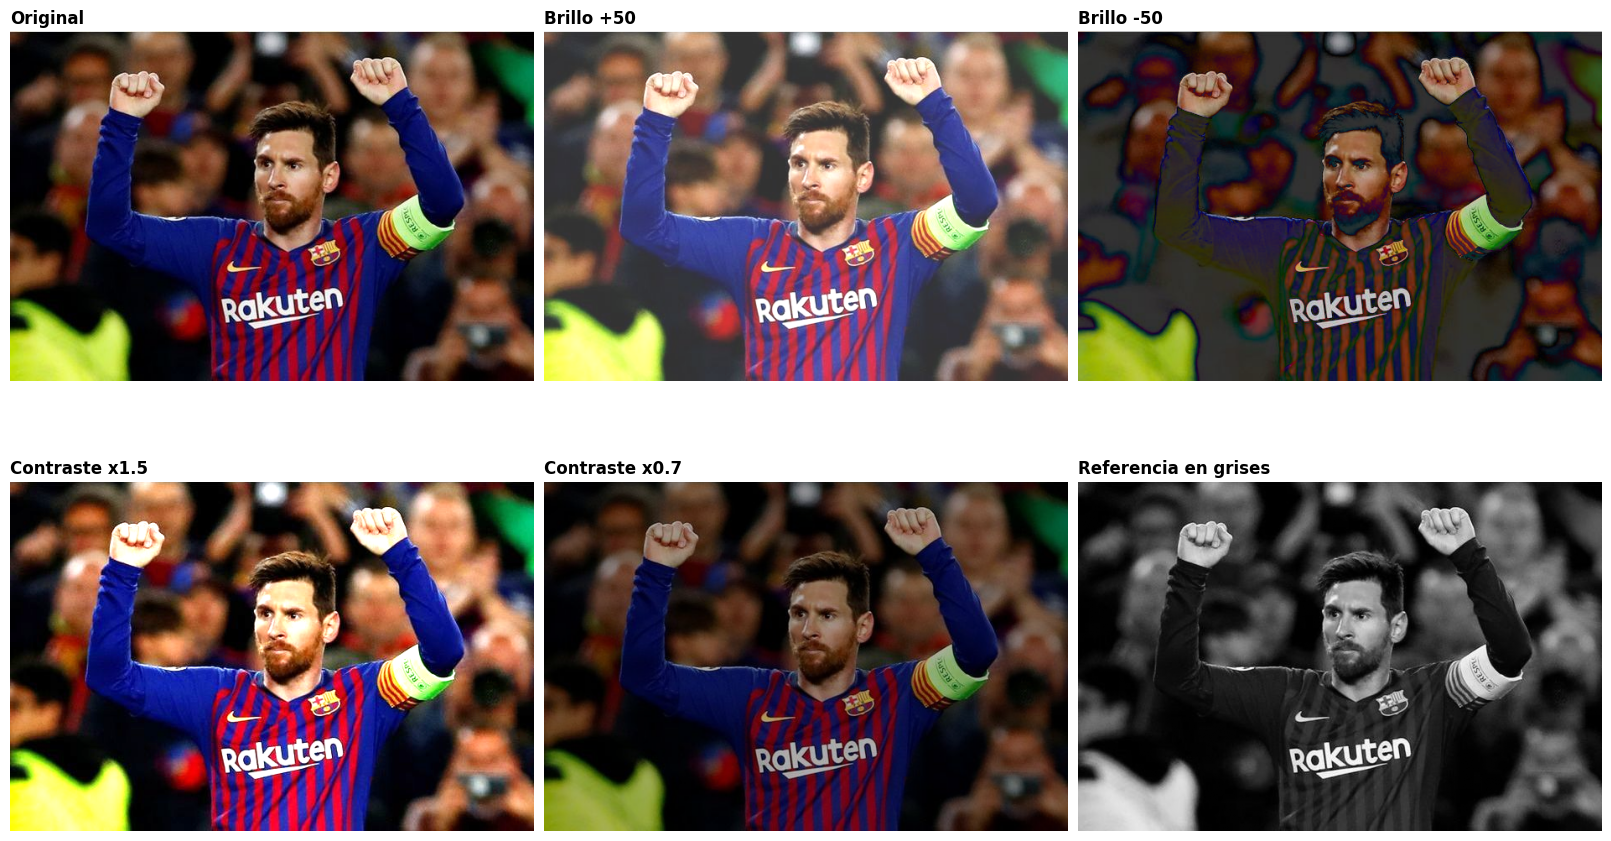

In [ ]:
# Mostramos una comparación visual de las variantes generadas.
fig, ejes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)

# Primera fila: imagen original y cambios de brillo.
ejes[0, 0].imshow(imagen_rgb)
ejes[0, 0].set_title('Original', fontweight='bold', loc='left')
ejes[0, 0].axis('off')

ejes[0, 1].imshow(imagen_brillo_alto)
ejes[0, 1].set_title('Brillo +50', fontweight='bold', loc='left')
ejes[0, 1].axis('off')

ejes[0, 2].imshow(imagen_brillo_bajo)
ejes[0, 2].set_title('Brillo -50', fontweight='bold', loc='left')
ejes[0, 2].axis('off')

# Segunda fila: cambios de contraste.
ejes[1, 0].imshow(imagen_contraste_alto)
ejes[1, 0].set_title('Contraste x1.5', fontweight='bold', loc='left')
ejes[1, 0].axis('off')

ejes[1, 1].imshow(imagen_contraste_bajo)
ejes[1, 1].set_title('Contraste x0.7', fontweight='bold', loc='left')
ejes[1, 1].axis('off')

ejes[1, 2].imshow(imagen_gris, cmap='gray')
ejes[1, 2].set_title('Referencia en grises', fontweight='bold', loc='left')
ejes[1, 2].axis('off')

plt.show()
# Organizamos varias versiones de la imagen en una figura para analizar de forma 
# comparativa los efectos del brillo, el contraste y la referencia en grises.


Compará qué cambia en cada caso. Cuando aumentás el brillo, toda la imagen se desplaza hacia tonos más claros. Cuando aumentás el contraste, las diferencias entre regiones claras y oscuras se vuelven más marcadas. Estas operaciones son simples, pero pueden modificar mucho el comportamiento de un algoritmo posterior.


## 7. Ajustar solo el brillo en HSV

Hasta acá modificaste la imagen directamente en RGB. Ahora vas a hacer un ajuste más selectivo: cambiar solo el canal `V` de HSV. Esta estrategia suele preservar mejor la percepción del color, porque no altera el matiz ni la saturación.


In [20]:
# Hacemos una copia de la imagen HSV para no modificar el original.
imagen_hsv_ajustada = imagen_hsv.copy()

# Definimos un factor de aumento para el canal de brillo.
factor_brillo = 1.3

# Ajustamos solo el canal V y limitamos los valores al rango válido.
canal_valor_ajustado = np.clip(imagen_hsv_ajustada[:, :, 2] * factor_brillo, 0, 255).astype(np.uint8)
imagen_hsv_ajustada[:, :, 2] = canal_valor_ajustado

# Convertimos nuevamente a RGB para poder visualizar el resultado.
imagen_hsv_mejorada = cv2.cvtColor(imagen_hsv_ajustada, cv2.COLOR_HSV2RGB)
# Mejoramos el brillo en HSV actuando solo sobre el canal de valor y convertimos la 
# imagen final a RGB.


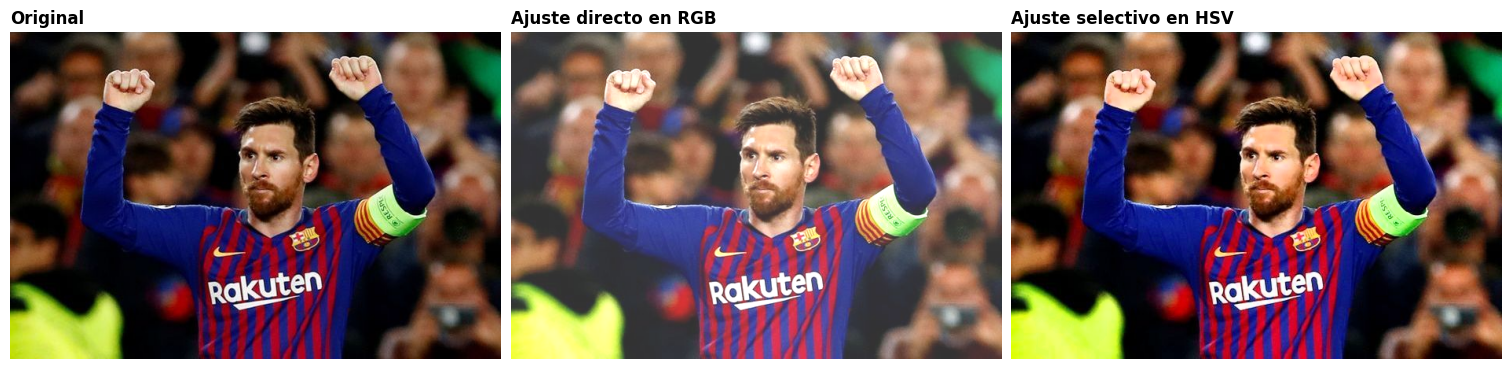

In [ ]:
# Comparamos la imagen original, el ajuste directo en RGB y el ajuste selectivo en HSV.
fig, ejes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

ejes[0].imshow(imagen_rgb)
ejes[0].set_title('Original', fontweight='bold', loc='left')
ejes[0].axis('off')

ejes[1].imshow(imagen_brillo_alto)
ejes[1].set_title('Ajuste directo en RGB', fontweight='bold', loc='left')
ejes[1].axis('off')

ejes[2].imshow(imagen_hsv_mejorada)
ejes[2].set_title('Ajuste selectivo en HSV', fontweight='bold', loc='left')
ejes[2].axis('off')

plt.show()

# Mostramos una comparación visual entre la imagen original, el aumento de brillo 
# aplicado en RGB y la mejora realizada solo sobre el canal V en HSV.



La diferencia puede ser sutil, pero conceptualmente es importante. En HSV modificaste solo la información de brillo. Eso muestra una ventaja de este espacio de color: permite intervenir una propiedad visual sin tocar necesariamente las demás.


## 8. Segmentación por color: un primer ejemplo de detección automática

En esta sección vas a construir una máscara que identifique regiones rojas dentro de una imagen. La idea central es simple: en lugar de analizar toda la escena por igual, vamos a conservar solo los píxeles que caen dentro de un rango de color que nos interesa.

Esta técnica no resuelve por sí sola todos los problemas de visión por computadora, pero sirve como base para entender tareas de detección, seguimiento y preprocesamiento.


In [22]:
# Leemos una imagen con objetos de varios colores para practicar segmentación.
imagen_segmentacion_bgr = cv2.imread(str(ruta_imagen_segmentacion))

# Verificamos que la carga haya sido correcta.
if imagen_segmentacion_bgr is None:
    raise FileNotFoundError(f'No se pudo leer la imagen: {ruta_imagen_segmentacion}')

# Convertimos la imagen a RGB y a HSV para trabajar con ambas representaciones.
imagen_segmentacion_rgb = cv2.cvtColor(imagen_segmentacion_bgr, cv2.COLOR_BGR2RGB)
imagen_segmentacion_hsv = cv2.cvtColor(imagen_segmentacion_rgb, cv2.COLOR_RGB2HSV)

print(f'Dimensiones de la imagen de segmentación: {imagen_segmentacion_rgb.shape}')


Dimensiones de la imagen de segmentación: (1024, 1024, 3)


Este bloque carga la imagen de segmentación y la convierte a los espacios RGB y HSV. RGB se utiliza para visualizarla correctamente, mientras que HSV facilita la segmentación por color al separar tono, saturación y brillo.


La utilidad de este bloque es preparar la imagen para trabajarla después. En concreto:

se lee desde disco para poder procesarla;

verificar que exista y se haya cargado bien;

se pasa a RGB para verla correctamente;

se convierte a HSV porque ese espacio de color es más útil para segmentar objetos según su color;

se imprimen sus dimensiones para saber cómo está formada la matriz de la imagen.

En este caso, lo hago para dejar lista la imagen globos.jpg para tareas de segmentación por color, por ejemplo detectar ciertos globos a partir de rangos de H, S y V.





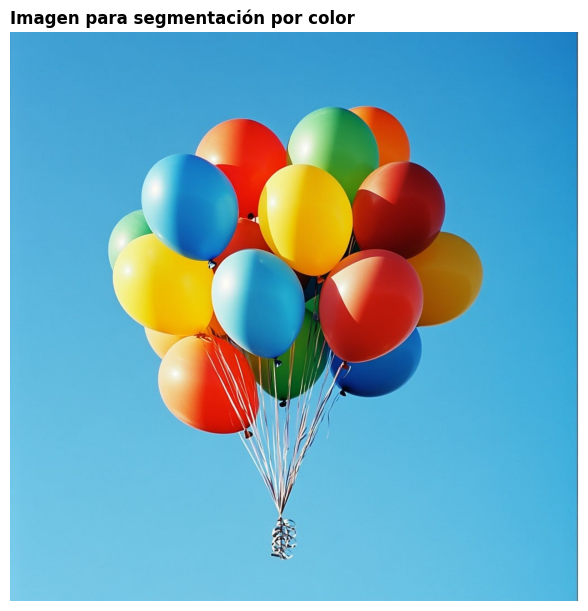

In [23]:
# Mostramos la imagen que vamos a segmentar.
plt.figure(figsize=(10, 6), constrained_layout=True)
plt.imshow(imagen_segmentacion_rgb)
plt.title('Imagen para segmentación por color', fontweight='bold', loc='left')
plt.axis('off')
plt.show()


## 9. Definir rangos para el color rojo

En HSV, el rojo tiene una particularidad: aparece cerca del inicio y del final de la rueda cromática. Por eso conviene definir dos rangos y después combinarlos.


In [24]:
# Definimos dos rangos para capturar el color rojo en HSV.
rojo_bajo_1 = np.array([0, 120, 70], dtype=np.uint8)
rojo_alto_1 = np.array([10, 255, 255], dtype=np.uint8)

rojo_bajo_2 = np.array([170, 120, 70], dtype=np.uint8)
rojo_alto_2 = np.array([179, 255, 255], dtype=np.uint8)

# Creamos una máscara para cada rango.
mascara_roja_1 = cv2.inRange(imagen_segmentacion_hsv, rojo_bajo_1, rojo_alto_1)
mascara_roja_2 = cv2.inRange(imagen_segmentacion_hsv, rojo_bajo_2, rojo_alto_2)

# Combinamos ambas máscaras para obtener una sola máscara roja.
mascara_roja = cv2.bitwise_or(mascara_roja_1, mascara_roja_2)


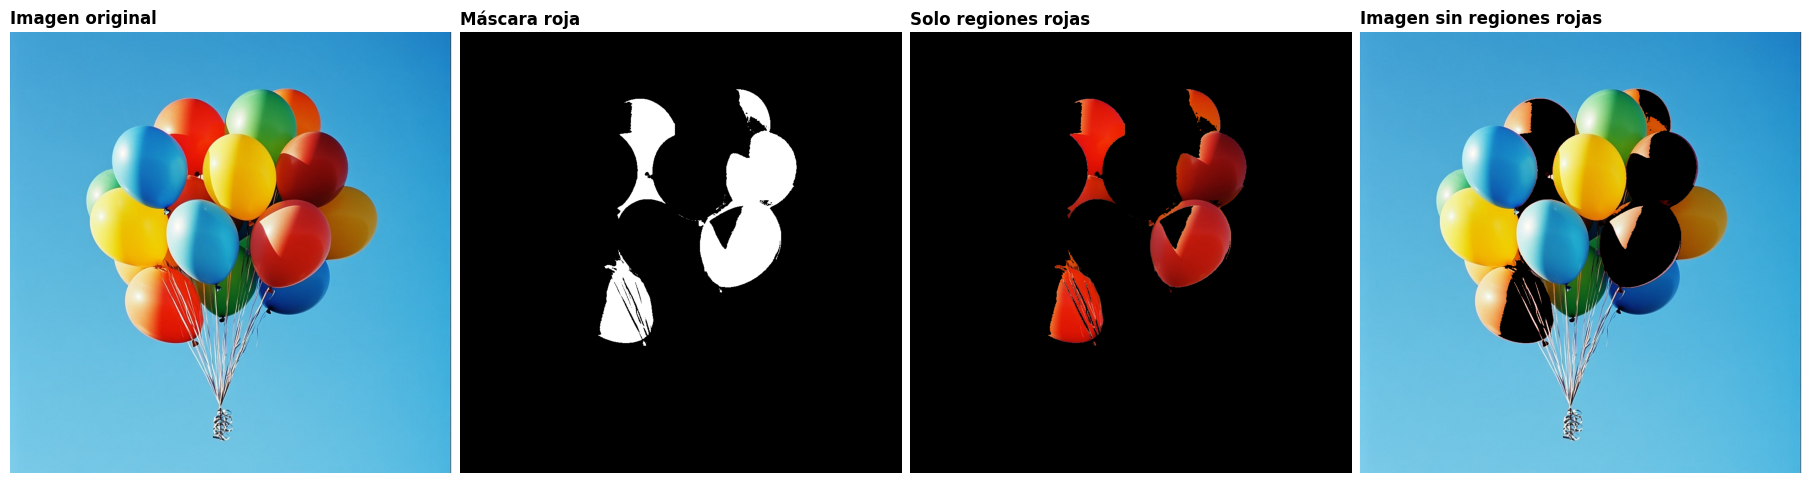

In [ ]:
# # Visualizamos qué partes rojas fueron segmentadas y cómo queda la imagen al quitarlas.
#Aplicamos la máscara sobre la imagen original.
imagen_solo_rojos = cv2.bitwise_and(imagen_segmentacion_rgb, imagen_segmentacion_rgb, mask=mascara_roja)

# También generamos la máscara inversa para ver el complemento.
mascara_invertida = cv2.bitwise_not(mascara_roja)
imagen_sin_rojos = cv2.bitwise_and(imagen_segmentacion_rgb, imagen_segmentacion_rgb, mask=mascara_invertida)

# Visualizamos el proceso completo.
fig, ejes = plt.subplots(1, 4, figsize=(18, 5), constrained_layout=True)

ejes[0].imshow(imagen_segmentacion_rgb)
ejes[0].set_title('Imagen original', fontweight='bold', loc='left')
ejes[0].axis('off')

ejes[1].imshow(mascara_roja, cmap='gray')
ejes[1].set_title('Máscara roja', fontweight='bold', loc='left')
ejes[1].axis('off')

ejes[2].imshow(imagen_solo_rojos)
ejes[2].set_title('Solo regiones rojas', fontweight='bold', loc='left')
ejes[2].axis('off')

ejes[3].imshow(imagen_sin_rojos)
ejes[3].set_title('Imagen sin regiones rojas', fontweight='bold', loc='left')
ejes[3].axis('off')

plt.show()

#Este bloque aplica la máscara roja sobre la imagen para aislar las regiones detectadas y 
# también genera su complemento para visualizar la imagen sin esos píxeles. 
# De esta manera se puede evaluar con claridad el resultado de la segmentación por color.


Con este bloque lográs aplicar una segmentación por color para separar las regiones rojas del resto de la imagen.

Más concretamente:

imagen_solo_rojos: conserva únicamente los píxeles que pertenecen a la máscara roja; el resto queda en negro.

mascara_invertida: invierte la selección, o sea, lo que era rojo deja de estar seleccionado y se selecciona el resto.

imagen_sin_rojos: muestra la imagen original pero quitando las regiones rojas.


La utilidad de hacer esto es:

aislar objetos o zonas de un color específico;

comprobar si el rango HSV elegido segmenta bien;

comparar visualmente qué parte de la imagen entra en la máscara y cuál queda afuera;

preparar una etapa posterior de análisis, conteo o detección de objetos.

En este caso, con globos.jpg, sirve para ver si la máscara roja está detectando correctamente los globos rojos y para evaluar qué tan limpia o precisa quedó la segmentación.



Fijate que la máscara binaria funciona como un filtro. Los píxeles blancos son los que cumplen la condición que definimos y los negros quedan excluidos. Esta lógica de selección es central en muchas tareas de segmentación, conteo y seguimiento de objetos.


## 10. Extender la idea a varios colores

Una vez que entendés cómo construir una máscara para un color, el procedimiento se puede repetir con otros rangos. Esto permite detectar varias clases simples dentro de una misma escena.


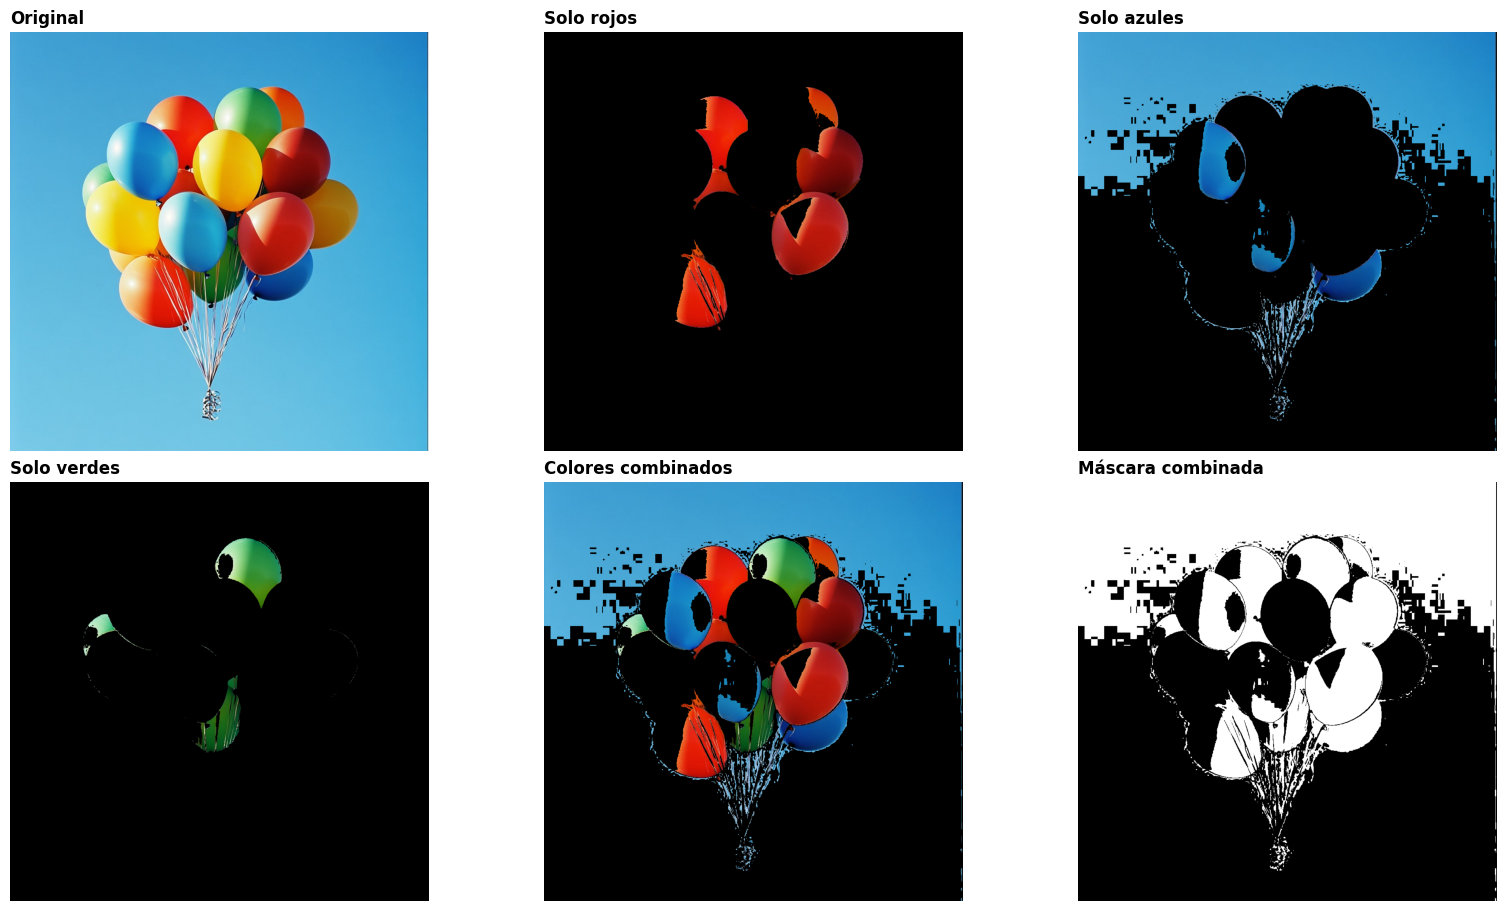

In [ ]:
# Definimos rangos aproximados para azul y verde en HSV.
azul_bajo = np.array([100, 50, 50], dtype=np.uint8)
azul_alto = np.array([130, 255, 255], dtype=np.uint8)

verde_bajo = np.array([40, 40, 40], dtype=np.uint8)
verde_alto = np.array([80, 255, 255], dtype=np.uint8)

# Creamos las máscaras correspondientes.
mascara_azul = cv2.inRange(imagen_segmentacion_hsv, azul_bajo, azul_alto)
mascara_verde = cv2.inRange(imagen_segmentacion_hsv, verde_bajo, verde_alto)

# Aplicamos cada máscara sobre la imagen original.
imagen_solo_azules = cv2.bitwise_and(imagen_segmentacion_rgb, imagen_segmentacion_rgb, mask=mascara_azul)
imagen_solo_verdes = cv2.bitwise_and(imagen_segmentacion_rgb, imagen_segmentacion_rgb, mask=mascara_verde)

# Combinamos todas las máscaras para ver el conjunto de colores detectados.
mascara_combinada = cv2.bitwise_or(mascara_roja, cv2.bitwise_or(mascara_azul, mascara_verde))
imagen_colores_combinados = cv2.bitwise_and(imagen_segmentacion_rgb, imagen_segmentacion_rgb, mask=mascara_combinada)

# Mostramos el resultado de las tres segmentaciones.
fig, ejes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)

ejes[0, 0].imshow(imagen_segmentacion_rgb)
ejes[0, 0].set_title('Original', fontweight='bold', loc='left')
ejes[0, 0].axis('off')

ejes[0, 1].imshow(imagen_solo_rojos)
ejes[0, 1].set_title('Solo rojos', fontweight='bold', loc='left')
ejes[0, 1].axis('off')

ejes[0, 2].imshow(imagen_solo_azules)
ejes[0, 2].set_title('Solo azules', fontweight='bold', loc='left')
ejes[0, 2].axis('off')

ejes[1, 0].imshow(imagen_solo_verdes)
ejes[1, 0].set_title('Solo verdes', fontweight='bold', loc='left')
ejes[1, 0].axis('off')

ejes[1, 1].imshow(imagen_colores_combinados)
ejes[1, 1].set_title('Colores combinados', fontweight='bold', loc='left')
ejes[1, 1].axis('off')

ejes[1, 2].imshow(mascara_combinada, cmap='gray')
ejes[1, 2].set_title('Máscara combinada', fontweight='bold', loc='left')
ejes[1, 2].axis('off')

plt.show()

#Este código permite segmentar varios colores en la imagen y comparar sus máscaras 
# individuales y combinadas. Su utilidad es analizar qué tan bien los rangos HSV 
# representan cada color y cómo pueden emplearse para detectar objetos de interés según su color.


Este código te sirve para comprobar cómo funciona la segmentación por color cuando buscás varios colores a la vez en una misma imagen.

En concreto te permite:

detectar por separado las regiones azules, verdes y rojas;

comparar si los rangos HSV elegidos son razonables;

ver qué objetos o zonas de la imagen quedan incluidos en cada máscara;

combinar varias segmentaciones en una sola imagen;

entender cómo construir un detector simple basado en color.

La utilidad práctica es que no solo ves un color aislado, sino que aprendés a trabajar con varias clases cromáticas dentro de la misma escena. En una imagen como globos.jpg, eso ayuda a identificar distintos globos según su color y observar qué tan bien responde cada rango.

También te sirve para notar limitaciones:

algunos objetos pueden quedar incompletos;

pueden aparecer falsos positivos;

la iluminación y las sombras pueden afectar la máscara.

Acá conviene distinguir entre dos cosas: segmentar y entender. La segmentación logra aislar regiones por color, pero todavía no sabe qué objeto hay ahí. Para pasar de una región segmentada a una detección más completa, hacen falta pasos adicionales de análisis o modelos más complejos.


## 11. Limitaciones del enfoque

La segmentación por color es útil, pero tiene límites claros:

- en RGB, pequeñas variaciones de iluminación pueden cambiar mucho los valores de los píxeles;
- en escala de grises se pierde información cromática, así que no sirve para distinguir objetos solo por color;
- en HSV la segmentación mejora, pero siguen apareciendo problemas con sombras, reflejos, fondos similares o colores muy desaturados.

Por eso, en aplicaciones reales suele combinarse con otras estrategias: filtrado, operaciones morfológicas, contornos, aprendizaje automático o modelos de detección de objetos.


## Actividad breve

Tomá la imagen de los globos y probá detectar un color distinto de los que aparecen en este cuaderno. Para hacerlo:

1. elegí un color presente en la escena;
2. definí un rango en HSV que te parezca razonable;
3. generá la máscara correspondiente;
4. explicá qué resultado obtuviste y qué limitaciones encontraste.

Si querés ir un paso más allá, compará el resultado de segmentar ese color en RGB y en HSV, y justificá cuál de las dos opciones te resultó más estable.


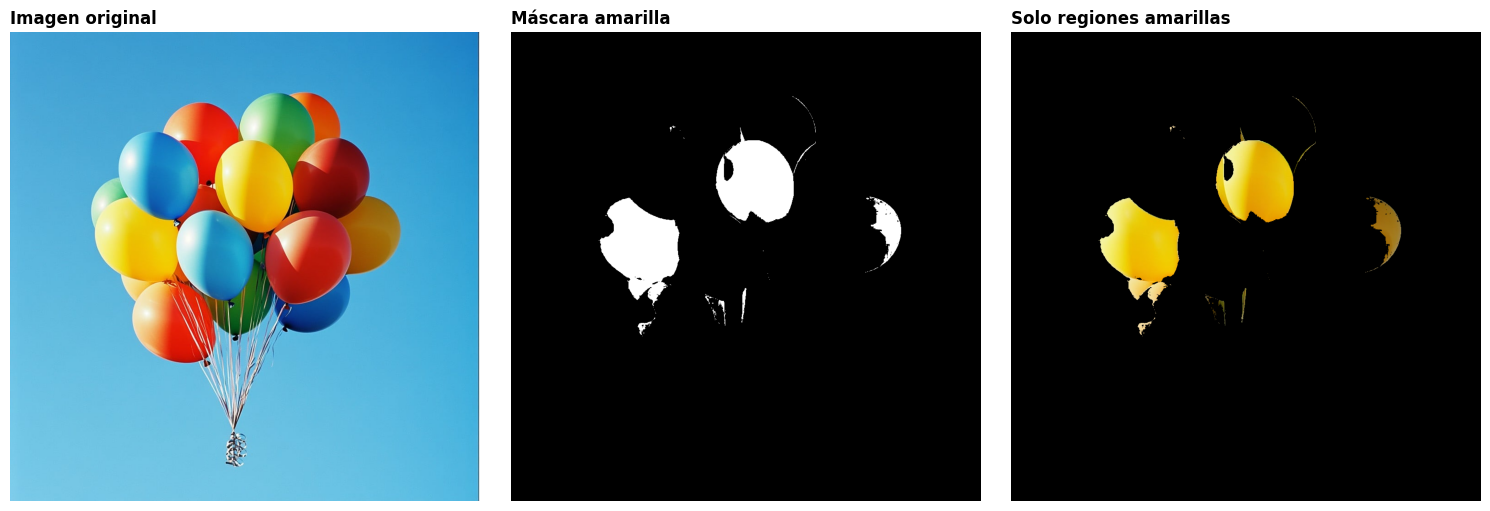

In [ ]:
# Definimos un rango aproximado para detectar amarillo en HSV.
amarillo_bajo = np.array([20, 80, 80], dtype=np.uint8)
amarillo_alto = np.array([35, 255, 255], dtype=np.uint8)

# Generamos la máscara binaria para el color amarillo.
mascara_amarilla = cv2.inRange(imagen_segmentacion_hsv, amarillo_bajo, amarillo_alto)

# Aplicamos la máscara sobre la imagen original para aislar las regiones amarillas.
imagen_solo_amarillos = cv2.bitwise_and(
    imagen_segmentacion_rgb,
    imagen_segmentacion_rgb,
    mask=mascara_amarilla
)

# Mostramos la imagen original, la máscara y el resultado final.
fig, ejes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

ejes[0].imshow(imagen_segmentacion_rgb)
ejes[0].set_title('Imagen original', fontweight='bold', loc='left')
ejes[0].axis('off')

ejes[1].imshow(mascara_amarilla, cmap='gray')
ejes[1].set_title('Máscara amarilla', fontweight='bold', loc='left')
ejes[1].axis('off')

ejes[2].imshow(imagen_solo_amarillos)
ejes[2].set_title('Solo regiones amarillas', fontweight='bold', loc='left')
ejes[2].axis('off')

plt.show()
# Definimos un rango HSV para detectar amarillo, generamos su máscara y visualizamos las 
# regiones segmentadas.



En esta prueba se eligió el color amarillo presente en la imagen de los globos. Para detectarlo se definió un rango aproximado en HSV, ya que este espacio de color separa mejor el tono del brillo. El resultado permitió aislar varias regiones amarillas de forma bastante clara mediante una máscara binaria y su aplicación sobre la imagen original.”

Como limitación, la segmentación depende de que el rango elegido sea adecuado. Algunas zonas amarillas pueden no detectarse completamente si cambian la iluminación, aparecen sombras o el color se vuelve menos saturado. También pueden aparecer falsos positivos en regiones con tonos parecidos.

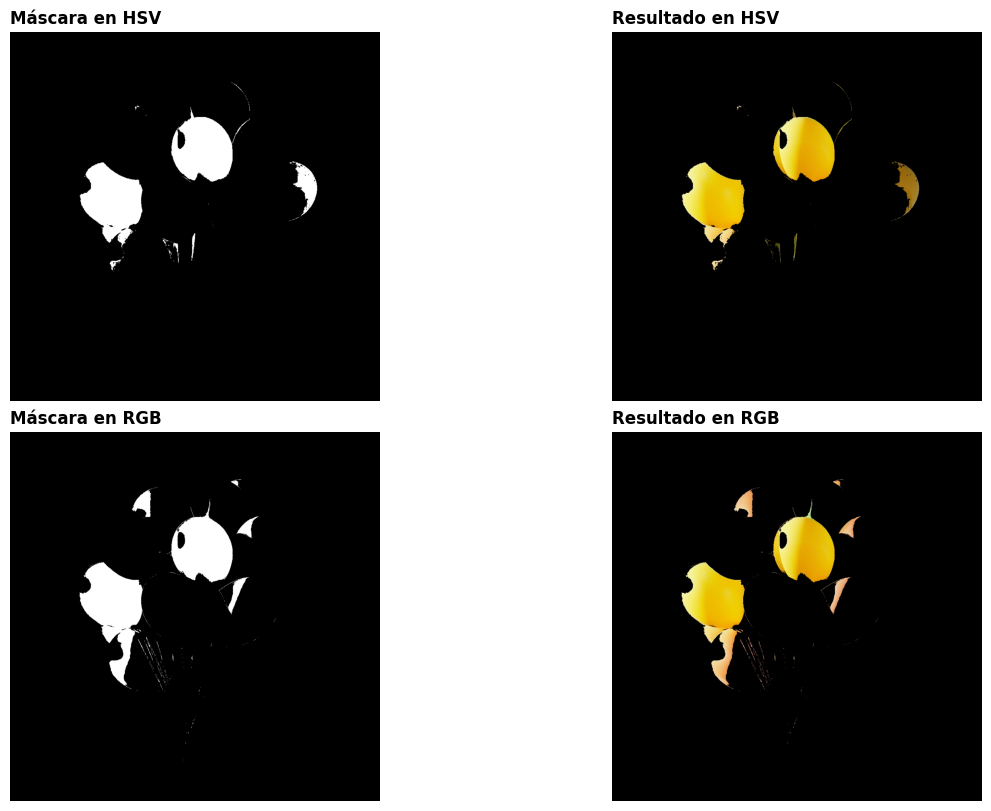

In [28]:
# Definimos un rango aproximado para amarillo en RGB.
amarillo_rgb_bajo = np.array([180, 150, 0], dtype=np.uint8)
amarillo_rgb_alto = np.array([255, 255, 170], dtype=np.uint8)

# Generamos la máscara en RGB.
mascara_amarilla_rgb = cv2.inRange(imagen_segmentacion_rgb, amarillo_rgb_bajo, amarillo_rgb_alto)

# Aplicamos la máscara RGB.
imagen_amarillo_rgb = cv2.bitwise_and(
    imagen_segmentacion_rgb,
    imagen_segmentacion_rgb,
    mask=mascara_amarilla_rgb
)

# Comparamos HSV y RGB.
fig, ejes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

ejes[0, 0].imshow(mascara_amarilla, cmap='gray')
ejes[0, 0].set_title('Máscara en HSV', fontweight='bold', loc='left')
ejes[0, 0].axis('off')

ejes[0, 1].imshow(imagen_solo_amarillos)
ejes[0, 1].set_title('Resultado en HSV', fontweight='bold', loc='left')
ejes[0, 1].axis('off')

ejes[1, 0].imshow(mascara_amarilla_rgb, cmap='gray')
ejes[1, 0].set_title('Máscara en RGB', fontweight='bold', loc='left')
ejes[1, 0].axis('off')

ejes[1, 1].imshow(imagen_amarillo_rgb)
ejes[1, 1].set_title('Resultado en RGB', fontweight='bold', loc='left')
ejes[1, 1].axis('off')

plt.show()


Al comparar ambos métodos, la segmentación en HSV suele resultar más estable que en RGB, porque permite trabajar sobre el tono de color de manera más directa y con menor dependencia de los cambios de iluminación.

## Cierre

En este cuaderno trabajaste una idea central de visión por computadora: una imagen puede representarse de distintas maneras según la tarea que querés resolver. RGB resulta natural para visualizar, la escala de grises simplifica la información y HSV suele ser más conveniente para separar color y brillo.

También viste que una imagen no es un objeto opaco, sino una estructura numérica sobre la que podemos medir, transformar y filtrar información. Esa perspectiva va a ser importante en los próximos cuadernos, donde estas representaciones se usan para segmentar mejor, detectar estructuras y preparar datos para algoritmos más complejos.


---

## Glosario mínimo

**Canal:** cada una de las capas de información de una imagen.

**Espacio de color:** forma de representar numéricamente los colores.

**HSV:** modelo que separa matiz, saturación y valor.

**Máscara:** imagen binaria que indica qué píxeles conservar o excluir.

**Píxel:** unidad mínima de una imagen digital.

**Preprocesamiento:** conjunto de transformaciones previas que preparan una imagen para un análisis posterior.
